In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.animation as animation
import pandas as pd


In [2]:
def create_cols_name(data):
    number_of_bodies = int(data.shape[1] / 3)
    cols = ['T']
    for body_number in range(number_of_bodies):
        for letter in ['X{}', 'Y{}', 'Z{}']:
            cols.append(letter.format(body_number))

    return cols

In [3]:
y = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 2, 3, 4, 5, 6, 7, 8, 9]
y = np.array(y)
y = np.array([y, y+10])

cols = create_cols_name(y)

df = pd.DataFrame(y, columns=cols)
df

,T,X0,Y0,Z0,X1,Y1,Z1,X2,Y2,Z2,X3,Y3,Z3,X4,Y4,Z4,X5,Y5,Z5
0,0,1,2,3,4,5,6,7,8,9,1,2,3,4,5,6,7,8,9
1,10,11,12,13,14,15,16,17,18,19,11,12,13,14,15,16,17,18,19


In [29]:
print(df['T'].to_json('split'))

None


In [7]:
positions = pd.read_csv(r"/home/mateus/Documents/TCC/src/n_body/output.txt", header=None)
# positions.columns = ["T","X1","Y1","Z1","X2","Y2","Z2","VX1","VY1","VZ1","VX2","VY2","VZ2"]
positions.columns = ["T","X1","Y1","X2","Y2"]
# positions.columns = ["T","X1","Y1","X2","Y2", "X3", "Y3", "X4", "Y4"]
positions

,T,X1,Y1,X2,Y2
0,0.000000e+00,0.000000e+00,0.000000e+00,1.496000e+08,0.000000e+00
1,4.748791e-05,6.725151e-43,2.119127e-54,1.496000e+08,1.414190e-03
2,5.223670e-04,8.137433e-41,2.820558e-51,1.496000e+08,1.555609e-02
3,5.271157e-03,8.286059e-39,2.898183e-48,1.496000e+08,1.569751e-01
4,5.275906e-02,8.300995e-37,2.906023e-45,1.496000e+08,1.571165e+00
...,...,...,...,...,...
8765,9.457008e+07,9.221500e-21,3.061550e-19,6.056575e+07,-1.396523e+08
8766,9.458088e+07,9.191826e-21,3.061745e-19,6.085225e+07,-1.395185e+08
8767,9.459168e+07,9.162178e-21,3.061939e-19,6.113850e+07,-1.393841e+08
8768,9.460248e+07,9.132558e-21,3.062132e-19,6.142448e+07,-1.392491e+08


In [6]:
positions[positions["T"] < 10]

,T,X1,Y1,X2,Y2
0,0.000000,0.000000e+00,0.000000e+00,1.496000e+08,0.000000
1,0.000047,6.725151e-44,2.119127e-55,1.496000e+08,0.001414
2,0.000522,8.137433e-42,2.820558e-52,1.496000e+08,0.015556
3,0.005271,8.286059e-40,2.898183e-49,1.496000e+08,0.156975
4,0.052759,8.300995e-38,2.906023e-46,1.496000e+08,1.571165
5,0.527638,8.302490e-36,2.906808e-43,1.496000e+08,15.713063
6,5.276429,8.302639e-34,2.906887e-40,1.496000e+08,157.132045


In [5]:
teste = positions.loc[:, positions.columns != 'T']

#teste.sub(teste["X1"], axis=0)
x_positions = positions.filter(regex='X')
y_positions = positions.filter(regex='Y')

x2_relative = x_positions.sub(x_positions["X2"], axis=0)
y2_relative = y_positions.sub(y_positions["Y2"], axis=0)

body2_relative = pd.concat([positions['T'], x2_relative, y2_relative], axis=1)

<IPython.core.display.Javascript object>


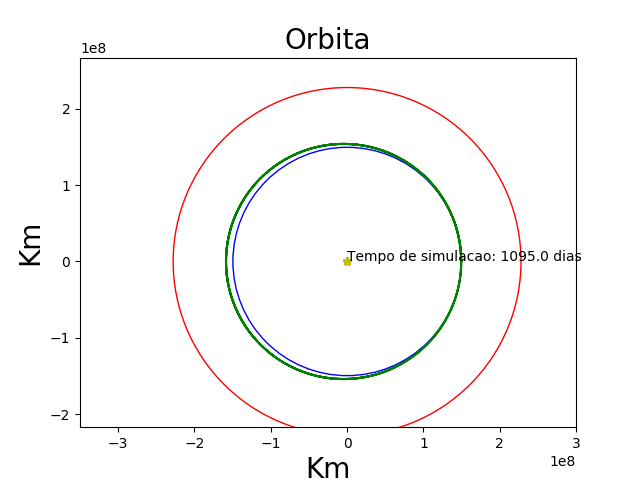

In [8]:
%matplotlib notebook

title = 'Orbita'
x_sat = np.array(positions['X2'])
y_sat = np.array(positions['Y2'])
writer = animation.FFMpegWriter(fps=24, metadata=dict(artist='Me'), bitrate=1800)

earth_orbit = plt.Circle((0,0), 1.496e8, fill=False, color='b')
mars_orbit = plt.Circle((0,0), 2.2794e8, fill=False, color='r')

fig = plt.figure()
ax = fig.gca()
# plt.xlim(-3.5e8, 3.5e8)
# plt.ylim(-3.5e8, 3.5e8)
# plt.xlim(np.min(x_sat) - 1e7, np.max(x_sat) + 1e7)
# plt.ylim(np.min(y_sat) - 1e7, np.max(y_sat) + 1e7)
ax.axis('equal')
ax.axis([-3.5e8, 3e8, -3.5e8, 4e8])
plt.xlabel('Km',fontsize=20)
plt.ylabel('Km',fontsize=20)
plt.title(title,fontsize=20)
text = plt.text(-15000, 0, "Tempo de simulacao: {} dias".format(np.max(positions['T'])/86400))

# final_time = int(positions['T'].iloc[-1]/60)

# def animate(i):
#    data = positions[positions['T'] <= i*60] #select data range
#    text.set_text("Tempo de simulacao: {} min".format(i))
#    plt.plot(data['X2'], data['Y2'], 'r')

#ani = animation.FuncAnimation(fig, animate, frames=final_time, repeat=False)
#ani.save("teste.mp4", writer=writer)

# plt.plot(positions['X2'], positions['Y2'],'b', 
#          positions["X1"], positions["Y1"], 'y-',
#          positions["X3"], positions["Y3"], 'g',
#          positions["X4"], positions["Y4"], 'r')

plt.plot(positions['X2'], positions['Y2'],'g', 
        positions["X1"], positions["Y1"], 'y-*')
ax.add_artist(earth_orbit)
ax.add_artist(mars_orbit)

In [ ]:
y2_relative.min().min()

In [ ]:
%matplotlib notebook

title = 'Orbita'
fig = plt.figure()
plt.xlim(x2_relative.min().min(), x2_relative.max().max())
plt.ylim(y2_relative.min().min(), y2_relative.max().max())
plt.xlabel('Km',fontsize=20)
plt.ylabel('Km',fontsize=20)
plt.title(title,fontsize=20)
text = plt.text(-15000, 0, "Tempo de simulacao: {} m".format(0))

final_time = int(positions['T'].iloc[-1]/(86400*15))

def animate(i):
    data = body2_relative[body2_relative['T'] <= i*86400*15] #select data range
    text.set_text("Tempo de simulacao: {} dias".format(i*15))
    plt.plot(data['X2'], data['Y2'],'b*', 
         data["X1"], data["Y1"], 'y-',
         data["X3"], data["Y3"], 'g',
         data["X4"], data["Y4"], 'r')

ani = animation.FuncAnimation(fig, animate, frames=final_time, repeat=False)
ani.save("teste.mp4", writer=writer)

#plt.plot(body2_relative['X2'], body2_relative['Y2'],'b*', 
#         body2_relative["X1"], body2_relative["Y1"], 'y-',
#         body2_relative["X3"], body2_relative["Y3"], 'g',
#         body2_relative["X4"], body2_relative["Y4"], 'r')

# plt.plot(positions['X2'], positions['Y2'],'r', 
#        positions["X1"], positions["Y1"], 'b-*')